In [1]:
!pip install -q gdown torch torchvision facenet-pytorch opencv-python-headless kagglehub kornia onnx onnxscript


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 6.1 MB/s eta 0:00:00


In [2]:
from google.colab import drive
import zipfile
drive.mount('/content/drive')

with zipfile.ZipFile('/content/drive/MyDrive/anyglasses_aligned_faces.zip', 'r') as z:
    z.extractall('/content/anyglasses_aligned_faces')


Mounted at /content/drive


In [3]:
import shutil
from pathlib import Path

misplaced_root_dir = Path("/content/anyglasses_aligned_faces/anyglasses_aligned_faces")
correct_target_dir = Path("/content/glasses_aligned_faces")

if misplaced_root_dir.exists():
    if correct_target_dir.exists():
        shutil.rmtree(correct_target_dir)
    shutil.move(str(misplaced_root_dir), str(correct_target_dir))
    print("Successfully moved directory")
else:
    print("Directory already in correct location")


Successfully moved directory


In [4]:
import os, shutil, warnings, time, collections
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights
import kornia.augmentation as K
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from pathlib import Path

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

ALIGNED_DIR = '/content/glasses_aligned_faces'
IMG_SIZE    = (224, 224)
IMAGE_EXTS  = {'.jpg', '.jpeg', '.png'}


Device: cuda


In [5]:
def build_cache(aligned_dir, class_names, label_map, cache_prefix, split_ratios=(0.80, 0.10, 0.10), img_size=(224, 224)):
    """
    Reads directly from aligned_dir/class_name, applies label_map,
    splits into train/val/test, and saves .npy caches.
    Returns (train_imgs, train_lbls, val_imgs, val_lbls, test_imgs, test_lbls)
    """
    cache_files = {
        split: (f'/content/{cache_prefix}_{split}_imgs.npy',
                f'/content/{cache_prefix}_{split}_lbls.npy')
        for split in ['train', 'val', 'test']
    }

    # Load from cache if all files exist
    if all(os.path.exists(p) for paths in cache_files.values() for p in paths):
        print(f"Cache found for '{cache_prefix}', loading...")
        results = []
        for split in ['train', 'val', 'test']:
            ci, cl = cache_files[split]
            results += [np.load(ci, mmap_mode='r'), np.load(cl)]
        return results

    print(f"Building cache for '{cache_prefix}'...")

    # Collect all samples
    all_samples = []
    for cls in class_names:
        cls_dir = Path(aligned_dir) / cls
        if not cls_dir.exists():
            print(f"  WARNING: {cls_dir} not found, skipping")
            continue
        label = label_map[cls]
        for f in cls_dir.glob('*'):
            if f.suffix.lower() in IMAGE_EXTS:
                all_samples.append((str(f), label))

    np.random.shuffle(all_samples)
    n = len(all_samples)
    tr = int(n * split_ratios[0])
    vl = int(n * split_ratios[1])

    splits = {
        'train': all_samples[:tr],
        'val':   all_samples[tr:tr+vl],
        'test':  all_samples[tr+vl:],
    }

    results = []
    for split, samples in splits.items():
        imgs = np.zeros((len(samples), img_size[0], img_size[1], 3), dtype=np.uint8)
        lbls = np.zeros(len(samples), dtype=np.int64)
        for i, (path, label) in enumerate(samples):
            img = cv2.imread(path)
            imgs[i] = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            lbls[i] = label
            if i % 1000 == 0:
                print(f"  {split} {i}/{len(samples)}")
        ci, cl = cache_files[split]
        np.save(ci, imgs)
        np.save(cl, lbls)
        results += [np.load(ci, mmap_mode='r'), lbls]
        print(f"  {split}: {len(samples)} samples, "
              f"label dist: {dict(collections.Counter(lbls.tolist()))}")

    return results


class CachedDataset(Dataset):
    def __init__(self, imgs, lbls, transform=None):
        self.imgs      = imgs
        self.lbls      = lbls
        self.transform = transform

    def __len__(self):
        return len(self.lbls)

    def __getitem__(self, idx):
        img = torch.from_numpy(self.imgs[idx].copy()).permute(2, 0, 1).float().div(255)
        if self.transform:
            img = self.transform(img)
        return img, int(self.lbls[idx])


def make_loaders(train_imgs, train_lbls, val_imgs, val_lbls,
                 test_imgs, test_lbls, val_norm, batch_size=128):
    train_ds = CachedDataset(train_imgs, train_lbls, transform=None)
    val_ds   = CachedDataset(val_imgs,   val_lbls,   transform=val_norm)
    test_ds  = CachedDataset(test_imgs,  test_lbls,  transform=val_norm)
    kw = dict(num_workers=4, pin_memory=True, persistent_workers=True)
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True,  **kw),
        DataLoader(val_ds,   batch_size=batch_size, shuffle=False, **kw),
        DataLoader(test_ds,  batch_size=batch_size, shuffle=False, **kw),
        train_ds, val_ds, test_ds,
    )

val_norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
print("Dataset utils ready.")


Dataset utils ready.


In [6]:
def make_model(num_classes, device):
    model = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1)
    model.classifier = nn.Sequential(
        nn.Linear(576, 1024),
        nn.Hardswish(),
        nn.Dropout(0.5),
        nn.Linear(1024, num_classes),
    )
    model = model.to(device)
    try:
        model = torch.compile(model, mode='reduce-overhead')
        print("torch.compile enabled")
    except Exception as e:
        print(f"torch.compile unavailable: {e}")
    return model


def train_epoch(model, loader, optimizer, criterion, train_aug, device, scaler):
    model.train()
    total_loss = correct = total = 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        with torch.no_grad():
            x = train_aug(x)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
            out  = model(x)
            loss = criterion(out, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * x.size(0)
        correct    += (out.argmax(1) == y).sum().item()
        total      += x.size(0)
    return total_loss / total, correct / total


def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                out  = model(x)
                loss = criterion(out, y)
            total_loss += loss.item() * x.size(0)
            correct    += (out.argmax(1) == y).sum().item()
            total      += x.size(0)
    return total_loss / total, correct / total


def train_model(model, train_loader, val_loader, criterion, optimizer,
                train_aug, device, save_path, epochs=30,
                lr_patience=5, stop_patience=15):
    scaler  = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda'))
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_state   = None
    no_improve   = 0

    for epoch in range(epochs):
        t0 = time.time()
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion,
                                      train_aug, device, scaler)
        vl_loss, vl_acc = validate_epoch(model, val_loader, criterion, device)
        elapsed = time.time() - t0

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)

        print(f"Epoch {epoch+1}/{epochs} ({elapsed:.1f}s)  "
              f"tr_loss={tr_loss:.4f}  tr_acc={tr_acc:.4f}  "
              f"vl_loss={vl_loss:.4f}  vl_acc={vl_acc:.4f}")

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}
            torch.save(model.state_dict(), save_path)
            no_improve = 0
        else:
            no_improve += 1
            if no_improve % lr_patience == 0:
                for pg in optimizer.param_groups:
                    pg['lr'] *= 0.2
                print(f"  LR reduced -> {optimizer.param_groups[0]['lr']:.2e}")
            if no_improve >= stop_patience:
                print("Early stopping.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


def fine_tune(model, train_loader, val_loader, criterion,
              train_aug, device, save_path, epochs=15, lr=1e-4):
    # Freeze all, unfreeze last 5 feature layers + classifier
    for param in model.parameters():
        param.requires_grad = False
    try:
        backbone = model._orig_mod
    except AttributeError:
        backbone = model
    for layer in list(backbone.features.children())[-5:]:
        for param in layer.parameters():
            param.requires_grad = True
    for param in backbone.classifier.parameters():
        param.requires_grad = True

    optimizer_ft = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )
    return train_model(model, train_loader, val_loader, criterion, optimizer_ft,
                       train_aug, device, save_path, epochs=epochs,
                       lr_patience=5, stop_patience=10)


def evaluate(model, test_loader, criterion, class_names, device):
    test_loss, test_acc = validate_epoch(model, test_loader, criterion, device)
    print(f"Test Loss: {test_loss:.4f}   Test Accuracy: {test_acc:.4f}")

    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in test_loader:
            out = model(x.to(device))
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(y.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    print(classification_report(all_labels, all_preds, target_names=class_names))


def plot_history(*histories):
    combined = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    for h in histories:
        for k in combined:
            combined[k].extend(h[k])
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    ax1.plot(combined['train_acc'], label='Train')
    ax1.plot(combined['val_acc'],   label='Val')
    ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(True)
    ax2.plot(combined['train_loss'], label='Train')
    ax2.plot(combined['val_loss'],   label='Val')
    ax2.set_title('Loss'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(True)
    plt.tight_layout(); plt.show()


def export_onnx(model, save_path, device):
    try:
        m = model._orig_mod
    except AttributeError:
        m = model
    m.eval()
    dummy = torch.randn(1, 3, 224, 224).to(device)
    torch.onnx.export(
        m, dummy, save_path,
        export_params=True, opset_version=11, do_constant_folding=True,
        input_names=['input'], output_names=['output'],
        dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
    )
    print(f"Saved {save_path}")

print("Training utils ready.")


Training utils ready.


In [7]:
S1_LABEL_MAP  = {'no_glasses': 0, 'glasses': 1}
S1_CLASS_NAMES = ['no_glasses', 'glasses']

train_aug_s1 = nn.Sequential(
    K.RandomHorizontalFlip(p=0.5),
    K.ColorJitter(brightness=0.2, contrast=0.2),
    K.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
).to(device)

s1_data = build_cache(
    ALIGNED_DIR,
    class_names=['no_glasses', 'glasses'],
    label_map=S1_LABEL_MAP,
    cache_prefix='s1',
)
s1_train_loader, s1_val_loader, s1_test_loader, *_ = make_loaders(*s1_data, val_norm)
print("Stage 1 loaders ready.")


Building cache for 's1'...
  train 0/22000
  train 1000/22000
  train 2000/22000
  train 3000/22000
  train 4000/22000
  train 5000/22000
  train 6000/22000
  train 7000/22000
  train 8000/22000
  train 9000/22000
  train 10000/22000
  train 11000/22000
  train 12000/22000
  train 13000/22000
  train 14000/22000
  train 15000/22000
  train 16000/22000
  train 17000/22000
  train 18000/22000
  train 19000/22000
  train 20000/22000
  train 21000/22000
  train: 22000 samples, label dist: {1: 9945, 0: 12055}
  val 0/2750
  val 1000/2750
  val 2000/2750
  val: 2750 samples, label dist: {1: 1298, 0: 1452}
  test 0/2750
  test 1000/2750
  test 2000/2750
  test: 2750 samples, label dist: {0: 1493, 1: 1257}
Stage 1 loaders ready.


In [8]:
s1_model     = make_model(num_classes=2, device=device)
s1_criterion = nn.CrossEntropyLoss()
s1_optimizer = optim.Adam(s1_model.parameters(), lr=1e-3)

s1_model, s1_hist_p1 = train_model(
    s1_model, s1_train_loader, s1_val_loader,
    s1_criterion, s1_optimizer, train_aug_s1,
    device, save_path='s1_best.pth', epochs=30,
)


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 166MB/s]


torch.compile enabled


W0620 07:57:17.563000 842 torch/_inductor/utils.py:1731] [0/0] Not enough SMs to use max_autotune_gemm mode


Epoch 1/30 (316.4s)  tr_loss=0.1425  tr_acc=0.9507  vl_loss=0.5085  vl_acc=0.7167
Epoch 2/30 (49.1s)  tr_loss=0.0859  tr_acc=0.9696  vl_loss=0.0985  vl_acc=0.9680
Epoch 3/30 (41.5s)  tr_loss=0.0668  tr_acc=0.9769  vl_loss=0.2343  vl_acc=0.9058
Epoch 4/30 (36.0s)  tr_loss=0.0516  tr_acc=0.9820  vl_loss=0.1377  vl_acc=0.9665
Epoch 5/30 (36.0s)  tr_loss=0.0426  tr_acc=0.9847  vl_loss=0.1276  vl_acc=0.9615
Epoch 6/30 (39.2s)  tr_loss=0.0394  tr_acc=0.9856  vl_loss=0.1613  vl_acc=0.9615
Epoch 7/30 (35.5s)  tr_loss=0.0313  tr_acc=0.9885  vl_loss=0.1625  vl_acc=0.9356
  LR reduced -> 2.00e-04
Epoch 8/30 (34.4s)  tr_loss=0.0142  tr_acc=0.9955  vl_loss=0.0928  vl_acc=0.9804
Epoch 9/30 (34.5s)  tr_loss=0.0062  tr_acc=0.9978  vl_loss=0.0995  vl_acc=0.9818
Epoch 10/30 (38.8s)  tr_loss=0.0042  tr_acc=0.9986  vl_loss=0.1100  vl_acc=0.9825
Epoch 11/30 (35.7s)  tr_loss=0.0037  tr_acc=0.9985  vl_loss=0.1297  vl_acc=0.9800
Epoch 12/30 (34.9s)  tr_loss=0.0034  tr_acc=0.9986  vl_loss=0.1252  vl_acc=0.9822

In [9]:
s1_model, s1_hist_p2 = fine_tune(
    s1_model, s1_train_loader, s1_val_loader,
    s1_criterion, train_aug_s1, device,
    save_path='s1_best.pth', epochs=15, lr=1e-4,
)


Epoch 1/15 (36.1s)  tr_loss=0.0028  tr_acc=0.9990  vl_loss=0.1430  vl_acc=0.9822
Epoch 2/15 (38.0s)  tr_loss=0.0030  tr_acc=0.9989  vl_loss=0.1380  vl_acc=0.9825
Epoch 3/15 (35.5s)  tr_loss=0.0025  tr_acc=0.9988  vl_loss=0.1588  vl_acc=0.9825
Epoch 4/15 (35.7s)  tr_loss=0.0020  tr_acc=0.9994  vl_loss=0.1454  vl_acc=0.9818
Epoch 5/15 (37.2s)  tr_loss=0.0019  tr_acc=0.9991  vl_loss=0.1522  vl_acc=0.9815
Epoch 6/15 (35.7s)  tr_loss=0.0016  tr_acc=0.9994  vl_loss=0.1665  vl_acc=0.9815
Epoch 7/15 (35.0s)  tr_loss=0.0009  tr_acc=0.9996  vl_loss=0.1692  vl_acc=0.9818
  LR reduced -> 2.00e-05
Epoch 8/15 (37.4s)  tr_loss=0.0012  tr_acc=0.9995  vl_loss=0.1700  vl_acc=0.9815
Epoch 9/15 (34.9s)  tr_loss=0.0010  tr_acc=0.9996  vl_loss=0.1702  vl_acc=0.9822
Epoch 10/15 (35.8s)  tr_loss=0.0007  tr_acc=0.9997  vl_loss=0.1728  vl_acc=0.9818
Epoch 11/15 (38.0s)  tr_loss=0.0009  tr_acc=0.9996  vl_loss=0.1771  vl_acc=0.9815
Epoch 12/15 (36.9s)  tr_loss=0.0010  tr_acc=0.9995  vl_loss=0.1764  vl_acc=0.9815


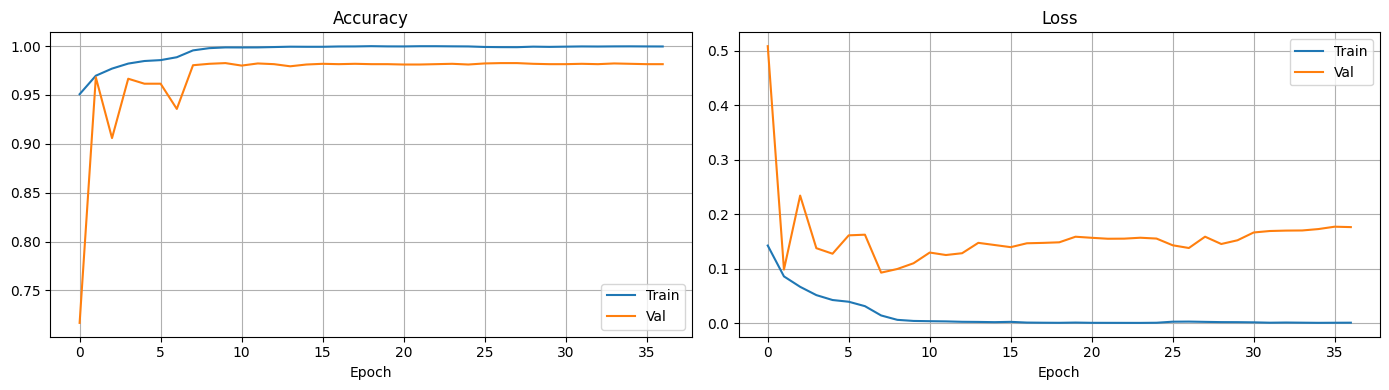

Test Loss: 0.0887   Test Accuracy: 0.9840


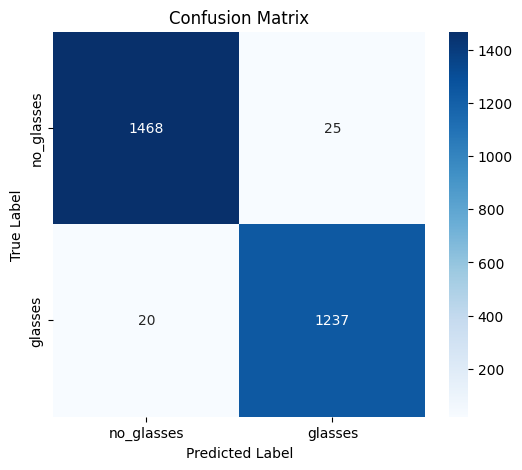

              precision    recall  f1-score   support

  no_glasses       0.99      0.98      0.98      1493
     glasses       0.98      0.98      0.98      1257

    accuracy                           0.98      2750
   macro avg       0.98      0.98      0.98      2750
weighted avg       0.98      0.98      0.98      2750



W0620 08:25:01.291000 842 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MobileNetV3([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /project/onnx/version_converter/adapters/axes_input_to_attribute.h:56: adapt: Assertion `node-

[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Saved glasses_binary.onnx


In [10]:
plot_history(s1_hist_p1, s1_hist_p2)
evaluate(s1_model, s1_test_loader, s1_criterion, S1_CLASS_NAMES, device)

torch.save(s1_model.state_dict(), 'glasses_binary.pth')
export_onnx(s1_model, 'glasses_binary.onnx', device)
